In [2]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

df1 = pd.read_csv("../PNN_round5_TuRBO/pairing_results_round5_data1.csv")

column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data1.csv",header=None, names=column_names)
hf2 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data2.csv",header=None, names=column_names)
hf3 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data3.csv",header=None, names=column_names)
hf4 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data4.csv",header=None, names=column_names)
hf5 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data5.csv",header=None, names=column_names)
hf6 = pd.read_csv("../PNN_round5_TuRBO/heatflux_all_round5_data6.csv",header=None, names=column_names)



      T3     T4     T5     T6     T7     T8     T9    T10     k1     k2  ...  \
0  0.432  0.511  0.238  0.445  0.315  0.077  0.761  0.855  0.676  0.388  ...   
1  0.747  0.359  0.833  0.048  0.283  0.424  0.746  0.629  0.729  0.153  ...   
2  0.409  0.459  0.864  0.536  0.278  0.153  0.876  0.926  0.281  0.374  ...   
3  0.842  0.440  0.524  0.503  0.327  0.097  0.123  0.841  0.430  0.197  ...   
4  0.561  0.246  0.688  0.240  0.272  0.426  0.831  0.546  0.639  0.160  ...   

     k11    k12    k13    k14    k15    k16    k17    k18    k19    k20  
0  0.859  0.103  0.268  0.175  0.095  0.336  0.338  0.105  0.419  0.273  
1  0.479  0.001  0.152  0.228  0.215  0.318  0.056  0.278  0.845  0.314  
2  0.329  0.387  0.064  0.241  0.007  0.078  0.382  0.171  0.320  0.143  
3  0.787  0.444  0.112  0.057  0.320  0.034  0.099  0.284  0.272  0.602  
4  0.492  0.166  0.200  0.030  0.092  0.281  0.155  0.318  0.280  0.255  

[5 rows x 28 columns]


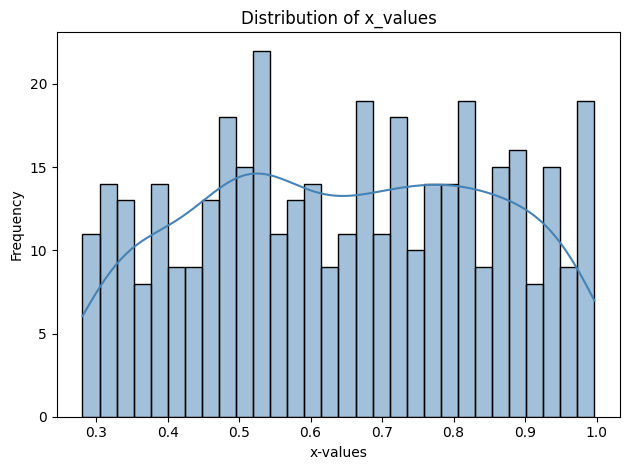

In [3]:
x_values = df1.iloc[:, 4:33]
# Apply the transformation only to the first column in x_values
x_values["T3"] = (1 + (250 - df1["T3"]) / 5)/2
x_values["T4"] = (1 + (250 - df1["T4"]) / 5)/2
x_values["T5"] = (1 + (250 - df1["T5"]) / 5)/2
x_values["T6"] = (1 + (250 - df1["T6"]) / 5)/2
x_values["T7"] = (1 + (200 - df1["T7"]) / 5)/2
x_values["T8"] = (1 + (200 - df1["T8"]) / 5)/2
x_values["T9"] = (1 + (150 - df1["T9"]) / 5)/2
x_values["T10"] = (1 + (150 - df1["T10"]) / 5)/2
for i in range(1, 21):
    col = f'k{i}'
    x_values[col] = df1[col] / 9

print(x_values.head())

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the first column
sns.histplot(x_values["k1"], kde=True, bins=30, color='steelblue')

plt.title(f"Distribution of x_values")
plt.xlabel("x-values")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Write to CSV file
import csv

x_values_rounded = x_values.round(3)

with open("round5_x_values.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(x_values_rounded.columns)          # write header
    writer.writerows(x_values_rounded.to_numpy())      # write data rows


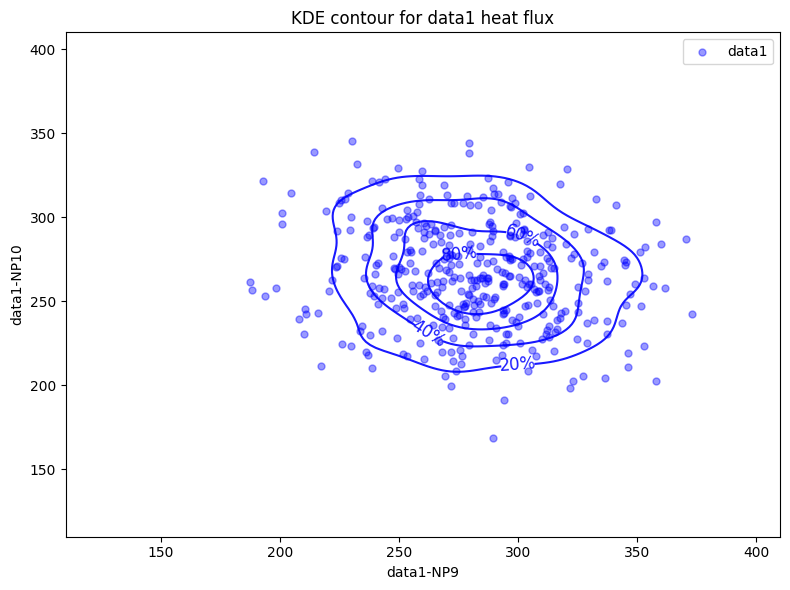

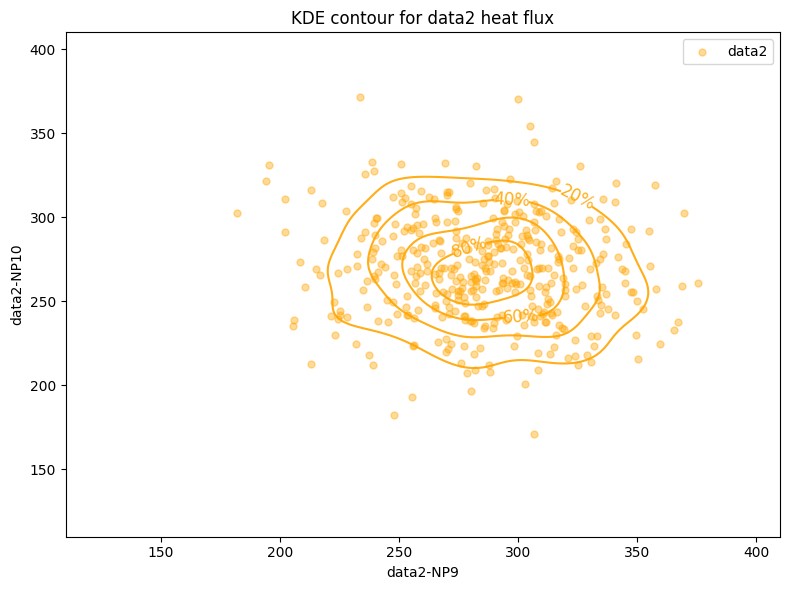

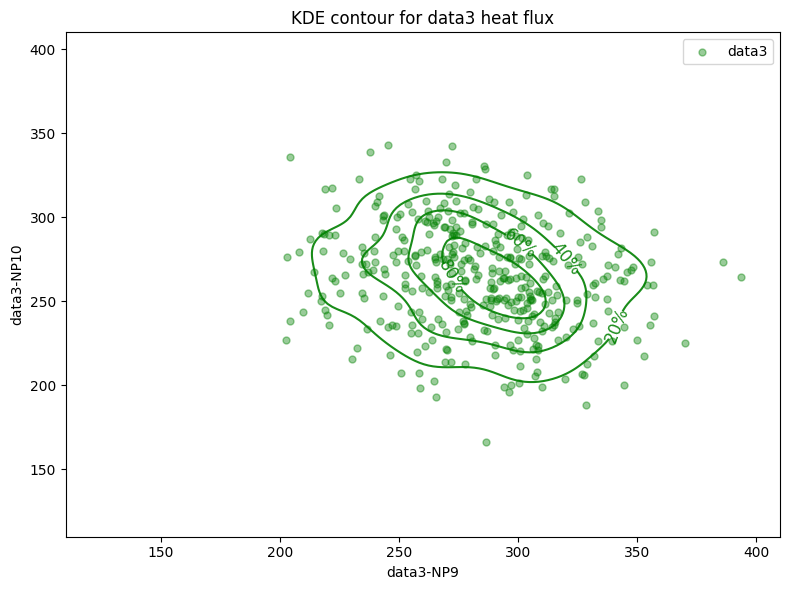

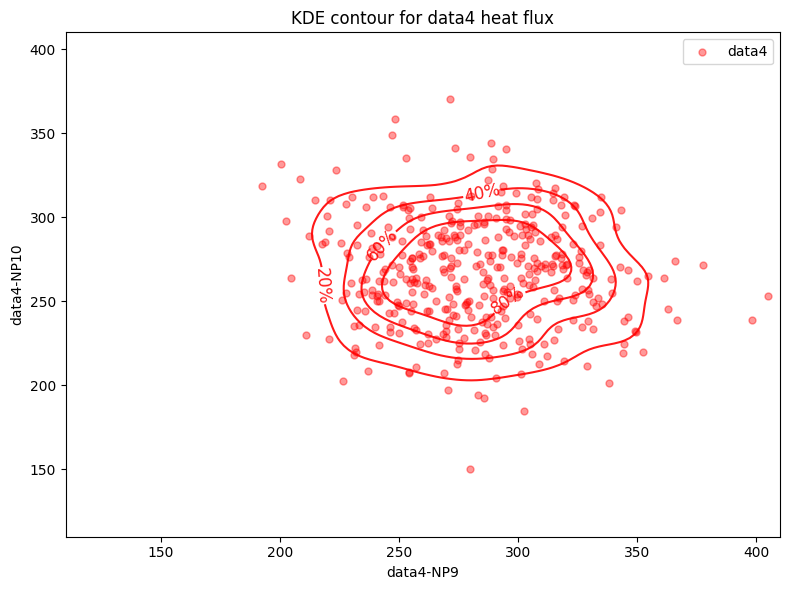

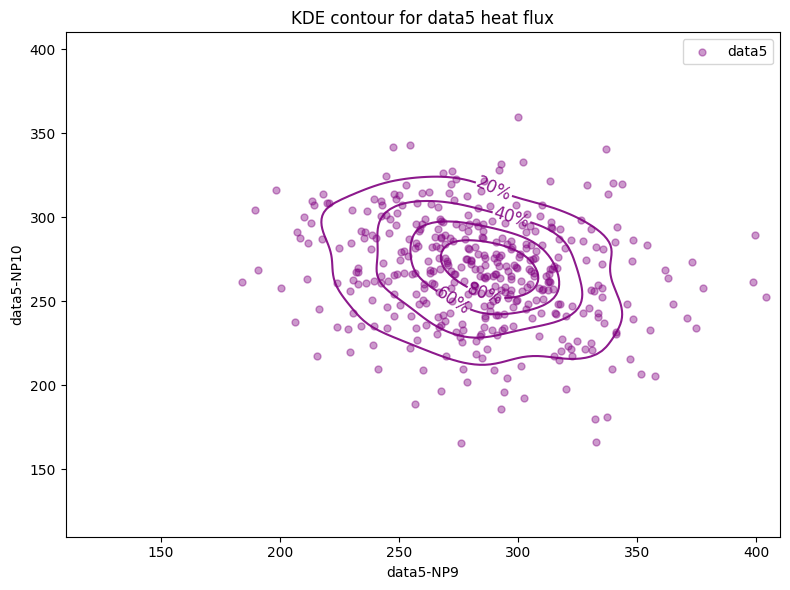

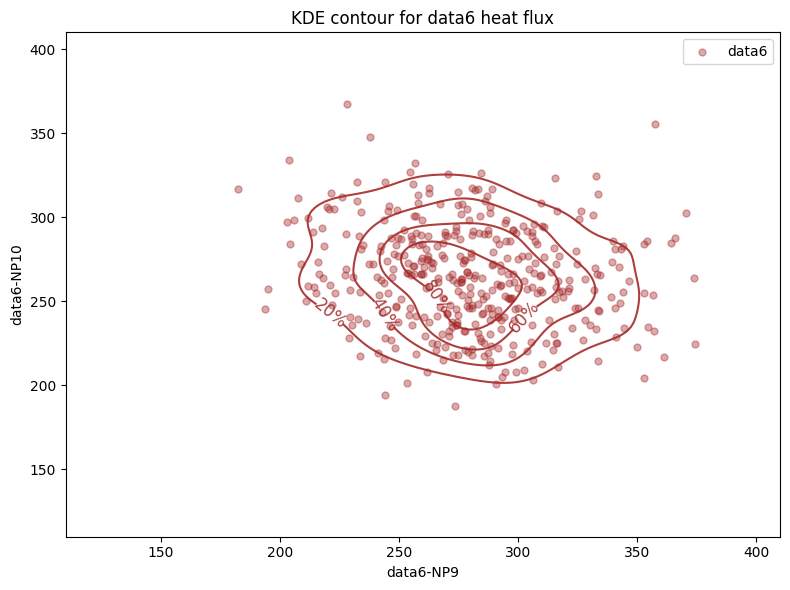

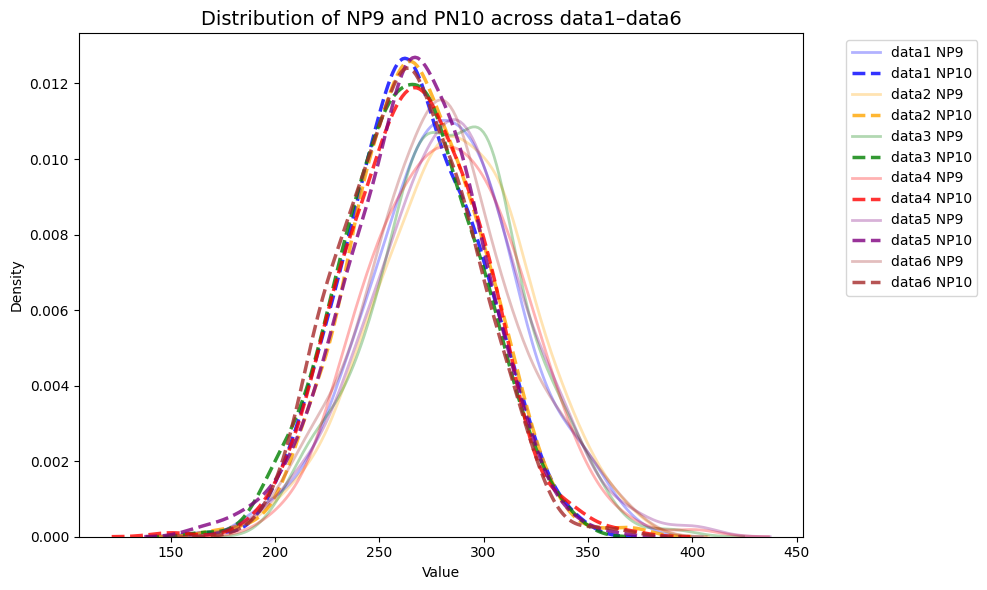

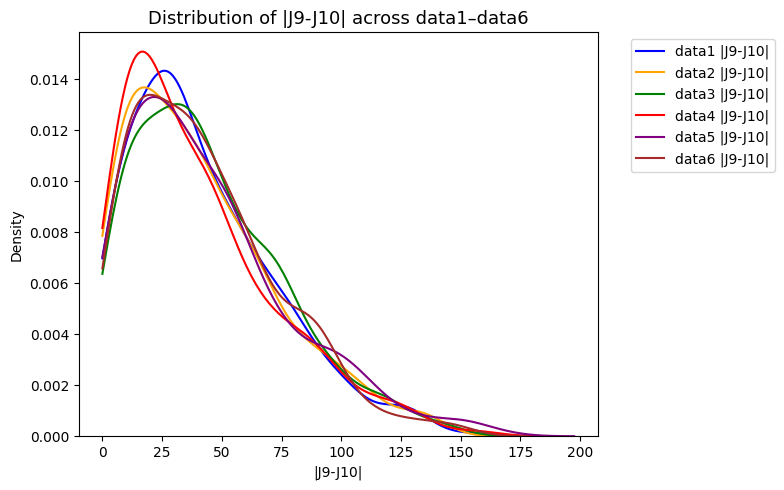

     pairing_num  FDR_distance
175          176     12.549178
230          231      9.984554
362          363      6.350841
295          296      5.747576
382          383      5.710277
..           ...           ...
299          300      0.000106
68            69      0.000059
183          184      0.000051
387          388      0.000049
154          155      0.000014

[400 rows x 2 columns]


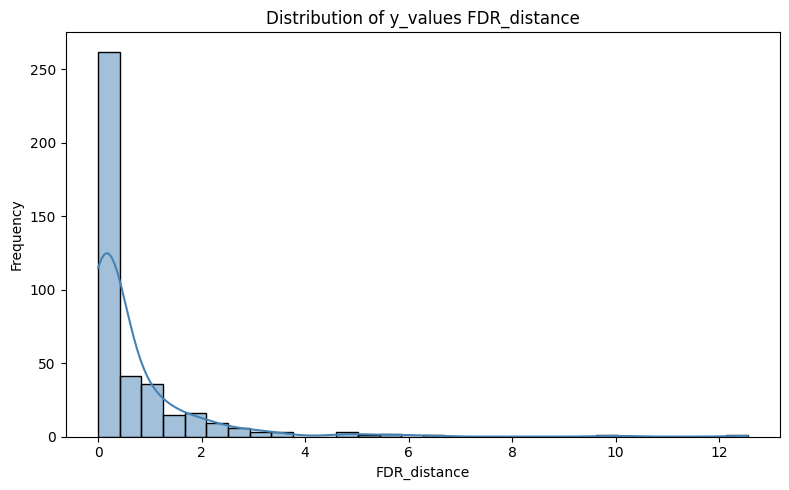

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets = [hf1, hf2, hf3, hf4, hf5, hf6]

labels = [f"data{i}" for i in range(1, 7)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

for df, label, base_color in zip(datasets, labels, base_colors):
    plt.figure(figsize=(8, 6))
    x = df.iloc[:, 8].values
    y = df.iloc[:, 9].values

    # Scatter points
    plt.scatter(x, y, s=25, alpha=0.4, color=base_color, label=f'{label}')

    # --- Compute KDE manually so we can label contours ---
    kde = gaussian_kde(np.vstack([x, y]))
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    # Create grid
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled = Z / Z.max() * 100  # 0–100%
    CS = plt.contour(X, Y, Z_scaled, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    plt.clabel(CS, inline=True, fontsize=12, fmt='%.0f%%')  # shows % of max density
    # --- Draw and label contours ---
    #CS = plt.contour(X, Y, Z, levels=5, colors=[base_color], linewidths=1.5, alpha=0.9)
    #plt.clabel(CS, inline=True, fontsize=8, fmt='%1.3f')  # Label with density values

    plt.xlabel(f'{label}-NP9')
    plt.ylabel(f'{label}-NP10')
    plt.xlim((110,410))
    plt.ylim((110,410))
    plt.legend()
    plt.title(f'KDE contour for {label} heat flux')
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(10, 6))

for df, label, base_color in zip(datasets, labels, base_colors):
    # lighter shade for column 9
    sns.kdeplot(df.iloc[:, 8],clip=(0, None), label=f'{label} NP9', color=base_color, alpha=0.3, linewidth=2)
    # darker shade for column 10
    sns.kdeplot(df.iloc[:, 9], label=f'{label} NP10', color=base_color, alpha=0.8, linewidth=2.5, linestyle='--')

plt.title('Distribution of NP9 and PN10 across data1–data6', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Compute the sum of column 9 and 10 for each dataframe
# (Python is 0-indexed, so column 9 → index 8, column 10 → index 9)
output = pd.DataFrame({
    f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)
    for i, df in enumerate(datasets)
})

# Plot KDE distributions for all (J9-J10)^2
plt.figure(figsize=(8, 5))
for i, (label, base_color) in enumerate(zip(labels, base_colors)):
    sns.kdeplot(output[f"col{i+1}"],clip=(0, None), label=f'{label} |J9-J10|', color=base_color, fill=False)

plt.title('Distribution of |J9-J10| across data1–data6', fontsize=13)
plt.xlabel('|J9-J10|')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Compare first 3 columns (0,1,2) with next 3 columns (3,4,5)
left = output.iloc[:, 0:3]
right = output.iloc[:, 3:6]

# Compute mean and variance per row for each 3D group
mu_A = output.iloc[:, 0:3].mean(axis=1)
mu_B = output.iloc[:, 3:6].mean(axis=1)
var_A = output.iloc[:, 0:3].var(axis=1, ddof=1)
var_B = output.iloc[:, 3:6].var(axis=1, ddof=1)

# Compute Fisher’s Discriminant Ratio (FDR) for each row 
output["FDR_distance"] = (mu_A - mu_B) ** 2 / (var_A + var_B + 1e-8)

# Also compute centroid (mean) distance per row for reference
output["centroid_distance"] = np.sqrt((mu_A - mu_B) ** 2)

# 1. Combine
combined = pd.concat([df1["pairing_num"],
                      #output["centroid_distance"],
                      output["FDR_distance"]], axis=1)

# 2. Sort by FDR_distance
combined_sorted = combined.sort_values(by="FDR_distance", ascending=False)

# 3. Print
print(combined_sorted)

# Extract FDR_distance column and round to 3 decimal places
y_values = output["FDR_distance"]

# Plot the distribution of y
fig = plt.figure(figsize=(8, 5))
sns.histplot(y_values, kde=True, bins=30, color='steelblue')

plt.title(f"Distribution of y_values FDR_distance")
plt.xlabel("FDR_distance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
fig.savefig(f"round5_Heat_flux_FDR_distance.pdf", format="pdf")

y_values_rounded = y_values.round(3)

# Convert to DataFrame to save as CSV
y_df = pd.DataFrame({"FDR_distance": y_values_rounded})

# Save to CSV
y_df.to_csv("round5_y_values.csv", index=False)
combined_sorted.to_csv("round5_y_values_sorted.csv", index=False)